<a href="https://colab.research.google.com/github/Viishnu07/DLI_GroupAE_URLPhishing/blob/main/Venus_Ong_Jin_Wen_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install dependencies
!pip install keras tensorflow --quiet
!pip install wget --quiet
!pip install tabulate --quiet
import os
import numpy as np
import string
import urllib.request
import wget
import seaborn as sns
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tabulate import tabulate
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

# Set random seed for reproducibility
np.random.seed(42)

  Preparing metadata (setup.py) ... done


In [13]:
# Step 1: Create folder
os.makedirs("dataset", exist_ok=True)
# Step 2: GitHub raw URLs
dataset_urls = {
    "train.txt": "https://media.githubusercontent.com/media/Viishnu07/DLI_GroupAE_URLPhishing/main/dataset/train.txt",
    "val.txt": "https://media.githubusercontent.com/media/Viishnu07/DLI_GroupAE_URLPhishing/main/dataset/val.txt",
    "test.txt": "https://media.githubusercontent.com/media/Viishnu07/DLI_GroupAE_URLPhishing/main/dataset/test.txt" }

# Step 3: Download each file
for filename, url in dataset_urls.items():
  print(f"Downloading {filename}...")
  urllib.request.urlretrieve(url, f"dataset/{filename}")
print("All files downloaded.")

# Load dataset (each line: "<label> <url>")
def load_dataset(file_path):
  urls, labels = [], []
  with open(file_path, 'r') as f:
    for line in f:
      parts = line.strip().split('\t') # Ensure it's tab-separated
      if len(parts) == 2:
        label_str, url = parts
        label = 1 if label_str.lower() == 'phishing' else 0
        urls.append(url)
        labels.append(label)
  return urls, labels

# Load using the downloaded files
train_urls, train_labels = load_dataset("dataset/train.txt")
val_urls, val_labels = load_dataset("dataset/val.txt")
test_urls, test_labels = load_dataset("dataset/test.txt")

All files downloaded.


In [14]:
# Char mapping
CHARS = string.printable
char2idx = {c: i + 1 for i, c in enumerate(CHARS)}  # 0 = padding
vocab_size = len(char2idx) + 1
MAX_LEN = 200

# Vectorization
def url_to_sequence(url):
    return [char2idx.get(c, 0) for c in url[:MAX_LEN]]

def vectorize_urls(urls):
    sequences = [url_to_sequence(url) for url in urls]
    return pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

X_train = vectorize_urls(train_urls)
X_val = vectorize_urls(val_urls)
X_test = vectorize_urls(test_urls)

y_train = to_categorical(train_labels, num_classes=2)
y_val = to_categorical(val_labels, num_classes=2)
y_test = to_categorical(test_labels, num_classes=2)

# Shape check
print(" All datasets loaded and vectorized:")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Vocab size:    {vocab_size}")

 All datasets loaded and vectorized:
X_train shape: (3641984, 200)
X_val shape:   (1045772, 200)
X_test shape:  (515080, 200)
y_train shape: (3641984, 2)
Vocab size:    101


In [15]:
# ----------------------------
# STEP 1: Split Training Dataset
# ----------------------------
X_train_1 = X_train[:1800000]
y_train_1 = y_train[:1800000]

X_train_2 = X_train[1800000:]
y_train_2 = y_train[1800000:]

# ----------------------------
# STEP 2: CNN1+ Model Definition
# ----------------------------
def build_cnn1_plus(vocab_size, max_len=200):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=50))

    model.add(Conv1D(filters=256, kernel_size=3, activation='relu'))
    model.add(BatchNormalization())

    model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))

    model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))

    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.4))
    model.add(Dense(2, activation='softmax'))

    return model

# ----------------------------
# STEP 3: Compile Model
# ----------------------------
model = build_cnn1_plus(vocab_size)

optimizer = Adam(learning_rate=0.001)

callbacks = [
    EarlyStopping(patience=2, restore_best_weights=True),
    ReduceLROnPlateau(patience=1, factor=0.5, min_lr=1e-5)
]

model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# ----------------------------
# STEP 4: Train on First Half
# ----------------------------
history1 = model.fit(
    X_train_1, y_train_1,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=1024,
    callbacks=callbacks,
    verbose=1
)

# ----------------------------
# STEP 5: Fine-Tune on Second Half
# ----------------------------
history2 = model.fit(
    X_train_2, y_train_2,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=1024,
    callbacks=callbacks,
    verbose=1
)

# ----------------------------
# STEP 6: Evaluate on Test Set
# ----------------------------
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

Epoch 1/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 192s 104ms/step - accuracy: 0.9534 - loss: 0.1092 - val_accuracy: 0.9815 - val_loss: 0.0479 - learning_rate: 0.0010
Epoch 2/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 188s 100ms/step - accuracy: 0.9841 - loss: 0.0417 - val_accuracy: 0.9856 - val_loss: 0.0380 - learning_rate: 0.0010
Epoch 3/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 177s 101ms/step - accuracy: 0.9870 - loss: 0.0346 - val_accuracy: 0.9868 - val_loss: 0.0348 - learning_rate: 0.0010
Epoch 4/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 200s 100ms/step - accuracy: 0.9885 - loss: 0.0306 - val_accuracy: 0.9857 - val_loss: 0.0372 - learning_rate: 0.0010
Epoch 5/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 176s 100ms/step - accuracy: 0.9915 - loss: 0.0230 - val_accuracy: 0.9893 - val_loss: 0.0300 - learning_rate: 5.0000e-04
Epoch 6/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 175s 99ms/step - accuracy: 0.9933 - loss: 0.0181 - val_accuracy: 0.9893 - val_loss: 0.0302 - learning_rate: 5.0000e-04
Epoch 7/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 204

Classification Report:

+--------------+-------------+----------+------------+-------------+
|              |   precision |   recall |   f1-score |     support |
+==============+=============+==========+============+=============+
| Legitimate   |      0.9908 |   0.9941 |     0.9925 | 285314      |
+--------------+-------------+----------+------------+-------------+
| Phishing     |      0.9927 |   0.9886 |     0.9906 | 229766      |
+--------------+-------------+----------+------------+-------------+
| accuracy     |      0.9917 |   0.9917 |     0.9917 |      0.9917 |
+--------------+-------------+----------+------------+-------------+
| macro avg    |      0.9918 |   0.9914 |     0.9916 | 515080      |
+--------------+-------------+----------+------------+-------------+
| weighted avg |      0.9917 |   0.9917 |     0.9917 | 515080      |
+--------------+-------------+----------+------------+-------------+


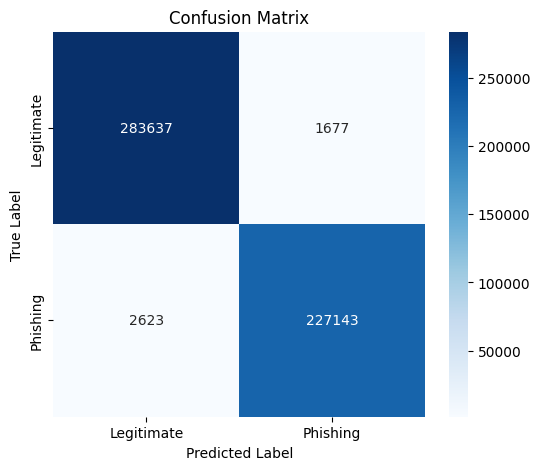

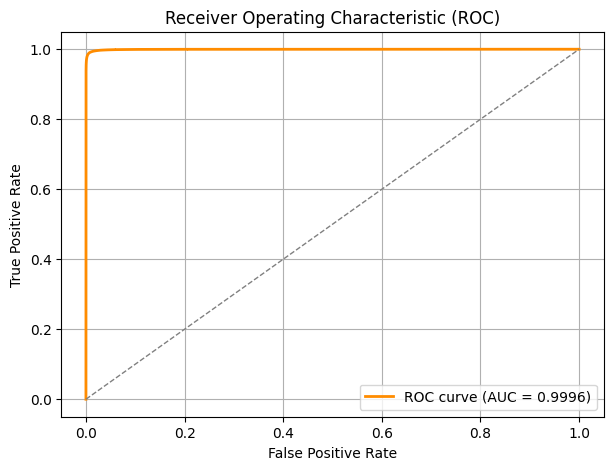

In [16]:
# ----------------------------
# STEP 7: Classification Report
# ----------------------------
report = classification_report(y_true, y_pred, target_names=['Legitimate', 'Phishing'], output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report = df_report[['precision', 'recall', 'f1-score', 'support']].round(4)

print("Classification Report:\n")
print(tabulate(df_report, headers='keys', tablefmt='grid'))

# ----------------------------
# STEP 8: Confusion Matrix
# ----------------------------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# ----------------------------
# STEP 9: ROC Curve
# ----------------------------
y_scores = y_pred_probs[:, 1]  # probability of class 1 (phishing)
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = roc_auc_score(y_true, y_scores)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [17]:
from keras.saving import save_model

# Save to local Colab file system
model.save("Venus_CNN.keras")

from google.colab import files

# Download to your computer
files.download("Venus_CNN.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>